# Anomaly-detection model benchmark: CLIP vs VLM

**Objective.** Find which of the candidate models is most suitable for detecting the
public-space anomalies in this project's datasets — **smoking, littering, rough sleeping**
(frame-level) and **loitering / unattended items** (temporal). We score each model on:

- **Accuracy & F1** — per-class, macro-F1, and binary anomaly-vs-normal F1 + ROC-AUC.
- **Inference speed** — latency p50/p95 and active throughput (samples/s), CPU float32.
- **Usability** — parameters, dependencies, whether it needs reference images, output type,
  memory footprint, integration effort.

## Models under test

| Model | Approach | In this harness? |
|---|---|---|
| MobileCLIP2-S2 | image↔text similarity (OpenCLIP port of Apple S2) | yes — frame-level |
| SigLIP2-B/16-224 | independent sigmoid image/text scores | yes — frame-level |
| SmolVLM-500M | generative VLM, deterministic JSON label | yes — frame-level |
| MiniCPM-V 4.0 | generative VLM (4.1B), single-image chat | yes — frame-level |
| **VadCLIP** | trained *temporal video* anomaly detector | **separate pipeline** (`scripts/vadclip.py`) |

> VadCLIP is a temporal detector whose checkpoints expect their original feature pipeline
> and UCF-Crime / XD-Violence labels, and it scores frame *sequences*. It is run through a
> dedicated script rather than forced into the single-frame CPU comparison.

## How to run

Run top-to-bottom in this notebook (or `jupyter nbconvert --execute`). The inference cells are
**idempotent**: if a model's results already exist for the current eval set they are reused, so
re-running is fast. Delete `results/bench/` to force a fresh full run.

Ground truth is derived from the datasets' own box annotations (see `scripts/build_manifest.py`):
smoking-video COCO gives clean *Smoking* vs *Not-Smoking* frames; littering YOLO boxes mark an
action; rough-sleeping pose marks laying vs standing. No weights are trained anywhere.

In [1]:
# ---- Configuration ----------------------------------------------------------
import json, sys, time, shutil, subprocess, hashlib
from pathlib import Path

def find_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "scripts" / "benchmark.py").exists():
            return cand
    raise RuntimeError("Could not locate project root (scripts/benchmark.py).")

ROOT = find_root()
sys.path.insert(0, str(ROOT))

# Frame-level models that run inside the existing benchmark harness.
MODELS = ["mobileclip2-s2", "siglip2-b16-224", "smolvlm-500m", "minicpm-v4"]
VADCLIP = "VadCLIP"  # separate pipeline

# Display names + a fixed categorical color per model (dataviz reference palette,
# slots 1-5 in validated order). Color follows the *entity* so each model keeps its
# hue across every chart.
MODEL_LABELS = {
    "mobileclip2-s2": "MobileCLIP2-S2",
    "siglip2-b16-224": "SigLIP2-B/16-224",
    "smolvlm-500m": "SmolVLM-500M",
    "minicpm-v4": "MiniCPM-V 4.0",
    "VadCLIP": "VadCLIP",
}
MODEL_COLORS = {
    "mobileclip2-s2": "#2a78d6",   # blue
    "siglip2-b16-224": "#1baf7a",  # aqua
    "smolvlm-500m": "#eda100",     # yellow
    "minicpm-v4": "#e87ba4",       # magenta
    "VadCLIP": "#eb6834",          # orange (separate pipeline)
}

# Per-model run budgets. duty-cycle 1 = no artificial pacing, so we measure raw speed.
THREADS = 4
TIMEOUT_S = {"mobileclip2-s2": 900, "siglip2-b16-224": 900,
             "smolvlm-500m": 1800, "minicpm-v4": 3600}
MAX_RSS_MB = {"minicpm-v4": 24576}   # ~24 GiB per README; others unbounded

# Balanced eval-set sizes.
BIN_PER_CLASS = 25    # normal + smoking -> head-to-head binary detection
MC_PER_CLASS = 12     # each of {normal,smoking,littering,rough_sleeping}
EXTENDED_N = 300      # larger set for the fast CLIP models (throughput/robustness)

SEED = 42
RESULTS = ROOT / "results" / "bench"
# Eval sets live in data/ (same dir as manifest.csv) so benchmark.py resolves the
# relative image paths against data/, exactly like the master manifest does.
EVALSETS = ROOT / "data"
FIGDIR = RESULTS / "figures"
RESULTS.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Frame-level models:", MODELS)

Project root: /home/g31/projects/test_here/capstone_S25
Frame-level models: ['mobileclip2-s2', 'siglip2-b16-224', 'smolvlm-500m', 'minicpm-v4']


In [2]:
# ---- Build the master manifest + balanced eval sets -------------------------
import csv
from scripts.build_manifest import build_master_manifest, stratified_subset, summarize

master_path = ROOT / "data" / "manifest.csv"
rows = build_master_manifest(out_path=master_path)      # writes data/manifest.csv
print(f"Master manifest: {len(rows)} labeled frames")
for label, count in sorted(summarize(rows).items()):
    print(f"  {label:16}{count}")

def write_evalset(name, per_class):
    subset = stratified_subset(rows, per_class, seed=SEED)
    path = EVALSETS / name
    with path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["path", "label", "split", "group_id"])
        for rel, label, group in subset:
            writer.writerow([rel, label, "test", group])
    return path

EVALSETS.mkdir(parents=True, exist_ok=True)
bin_manifest = write_evalset("eval_binary.csv", {"normal": BIN_PER_CLASS, "smoking": BIN_PER_CLASS})
mc_manifest = write_evalset("eval_multiclass.csv", {c: MC_PER_CLASS for c in
                        ["normal", "smoking", "littering", "rough_sleeping"]})
print(f"\n{bin_manifest.name}: {BIN_PER_CLASS} normal + {BIN_PER_CLASS} smoking (binary detection)")
print(f"{mc_manifest.name}: {MC_PER_CLASS} x 4 classes (multi-class type discrimination)")

Master manifest: 10110 labeled frames
  littering       6668
  normal          1909
  rough_sleeping  111
  smoking         1422

eval_binary.csv: 25 normal + 25 smoking (binary detection)
eval_multiclass.csv: 12 x 4 classes (multi-class type discrimination)


In [3]:
# ---- Runner: one model on one eval set, in an isolated worker ---------------
def run_model(model, manifest_path, evalset_name):
    """Run a single model via scripts/benchmark.py; reuse prior results if valid."""
    out_dir = RESULTS / evalset_name / model
    # benchmark.py requires --output to be a fresh dir and nests each model's files
    # under <out>/<model>/, so the per-model summary lives one level deeper than out_dir.
    summary_path = out_dir / model / "summary.json"

    # Reuse only if the previous run used this exact manifest and this one model.
    if summary_path.is_file():
        try:
            meta = json.loads((out_dir / "run.json").read_text(encoding="utf-8"))
            cur_hash = hashlib.sha256(manifest_path.read_bytes()).hexdigest()
            if meta.get("manifest_sha256") == cur_hash and meta.get("models") == [model]:
                print(f"[reuse] {MODEL_LABELS[model]} on {evalset_name}")
                return json.loads(summary_path.read_text(encoding="utf-8"))
        except Exception:
            pass

    if out_dir.exists():
        shutil.rmtree(out_dir)
    cmd = [sys.executable, str(ROOT / "scripts" / "benchmark.py"),
           "--manifest", str(manifest_path), "--models", model,
           "--limit", "0", "--seed", str(SEED), "--output", str(out_dir),
           "--timeout-seconds", str(TIMEOUT_S.get(model, 900)),
           "--threads", str(THREADS), "--duty-cycle", "1"]
    if model in MAX_RSS_MB:
        cmd += ["--max-rss-mb", str(MAX_RSS_MB[model])]

    print(f"[run] {MODEL_LABELS[model]} on {evalset_name} ...")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    for line in (proc.stdout or "").strip().splitlines()[-3:]:
        print("   ", line)
    if not summary_path.is_file():
        print(f"   !! no summary after {time.time()-t0:.0f}s; stderr tail:")
        for line in (proc.stderr or "").strip().splitlines()[-15:]:
            print("   ", line)
        return {"status": "error", "model": model}
    print(f"      finished in {time.time()-t0:.0f}s")
    return json.loads(summary_path.read_text(encoding="utf-8"))

In [4]:
# ---- Run every frame-level model on the head-to-head binary set ------------
binary_results = {}
for m in MODELS:
    binary_results[m] = run_model(m, bin_manifest, "eval_binary")
print("\nBinary-detection runs complete.")

[reuse] MobileCLIP2-S2 on eval_binary
[reuse] SigLIP2-B/16-224 on eval_binary
[reuse] SmolVLM-500M on eval_binary
[reuse] MiniCPM-V 4.0 on eval_binary

Binary-detection runs complete.


In [5]:
# ---- Run every frame-level model on the multi-class set ---------------------
mc_results = {}
for m in MODELS:
    mc_results[m] = run_model(m, mc_manifest, "eval_multiclass")
print("\nMulti-class runs complete.")

[reuse] MobileCLIP2-S2 on eval_multiclass
[reuse] SigLIP2-B/16-224 on eval_multiclass
[reuse] SmolVLM-500M on eval_multiclass
[reuse] MiniCPM-V 4.0 on eval_multiclass

Multi-class runs complete.


In [6]:
# ---- Extended throughput run for the fast CLIP models (optional) ------------
ext_manifest = write_evalset("eval_extended.csv", {"normal": EXTENDED_N // 2, "smoking": EXTENDED_N // 2})
extended_results = {}
for m in ["mobileclip2-s2", "siglip2-b16-224"]:
    extended_results[m] = run_model(m, ext_manifest, "eval_extended")
print(f"\nExtended ({EXTENDED_N}-frame) throughput runs complete.")

[reuse] MobileCLIP2-S2 on eval_extended
[reuse] SigLIP2-B/16-224 on eval_extended

Extended (300-frame) throughput runs complete.


In [7]:
# ---- VadCLIP: separate video pipeline ---------------------------------------
vad_report_path = ROOT / "results" / "vadclip" / "status.json"
proc = subprocess.run([sys.executable, str(ROOT / "scripts" / "vadclip.py"),
                       "--output", str(vad_report_path)], capture_output=True, text=True)
print(proc.stdout.strip())
vad_status = json.loads(vad_report_path.read_text(encoding="utf-8")) if vad_report_path.is_file() else {"status": "error"}
print(f"VadCLIP status: {vad_status.get('status')}")

VadCLIP not configured; wrote /home/g31/projects/test_here/capstone_S25/results/vadclip/status.json
VadCLIP status: not_configured


In [8]:
# ---- Assemble a tidy results table ------------------------------------------
def extract(summary):
    met = summary.get("metrics", {}) or {}
    binm = met.get("binary", {}) or {}
    tp = binm.get("tp") or 0; fp = binm.get("fp") or 0
    fn = binm.get("fn") or 0; tn = binm.get("tn") or 0
    n = tp + fp + fn + tn
    # True anomaly-vs-normal accuracy ((TP+TN)/N), so it pairs with Bin F1 / AUC.
    bin_acc = (tp + tn) / n if n else None
    return {
        "status": summary.get("status"),
        "accuracy": met.get("accuracy"),
        "macro_f1": met.get("macro_f1"),
        "bin_acc": bin_acc,
        "bin_f1": binm.get("f1"),
        "bin_auc": binm.get("roc_auc"),
        "coverage": met.get("prediction_coverage"),
        "abstain": summary.get("abstentions"),
        "errors": summary.get("errors"),
        "lat_p50": summary.get("latency_p50_seconds"),
        "lat_p95": summary.get("latency_p95_seconds"),
        "throughput": summary.get("active_samples_per_second"),
        "rss_mb": summary.get("peak_rss_mb"),
    }

def fmt(x, spec="{:.3f}"):
    return "n/a" if x is None else spec.format(x)

table = []
for m in MODELS + [VADCLIP]:
    row = {"model": MODEL_LABELS[m]}
    b = extract(binary_results.get(m, {})) if m != VADCLIP else {}
    c = extract(mc_results.get(m, {})) if m != VADCLIP else {}
    e = extract(extended_results.get(m, {})) if m in extended_results else {}
    row.update({
        "bin_acc": b.get("bin_acc"), "bin_f1": b.get("bin_f1"), "bin_auc": b.get("bin_auc"),
        "mc_acc": c.get("accuracy"), "mc_macro_f1": c.get("macro_f1"),
        "coverage": (b or c).get("coverage"), "abstain": (b or c).get("abstain"),
        # Speed: prefer the extended run for CLIP models, else the binary run.
        "lat_p95": e.get("lat_p95") or b.get("lat_p95"),
        "throughput": e.get("throughput") or b.get("throughput"),
        "rss_mb": max([x for x in [b.get("rss_mb"), c.get("rss_mb")] if x], default=None),
    })
    if m == VADCLIP:
        row["status"] = vad_status.get("status")
    else:
        row["status"] = b.get("status") or c.get("status")
    table.append(row)

def print_table(headers, rows):
    widths = [max(len(str(h)), *(len(str(r[i])) for r in rows)) for i, h in enumerate(headers)]
    def line(cells_): return "  ".join(str(c).ljust(widths[i]) for i, c in enumerate(cells_))
    print(line(headers)); print("  ".join("-" * w for w in widths))
    for r in rows: print(line(r))

acc_headers = ["Model", "Status", "Bin Acc", "Bin F1", "Bin AUC", "MC Acc", "MC macro-F1", "Coverage"]
acc_rows = [[r["model"], r["status"], fmt(r["bin_acc"]), fmt(r["bin_f1"]), fmt(r["bin_auc"]),
             fmt(r["mc_acc"]), fmt(r["mc_macro_f1"]), fmt(r["coverage"])] for r in table]
print("== Accuracy / F1 =="); print_table(acc_headers, acc_rows)

spd_headers = ["Model", "Lat p95 (s)", "Throughput (img/s)", "Peak RSS (MiB)", "Abstain"]
spd_rows = [[r["model"], fmt(r["lat_p95"]), fmt(r["throughput"], "{:.2f}"),
             fmt(r["rss_mb"], "{:.0f}"), r.get("abstain", "n/a")] for r in table]
print("\n== Speed / resources =="); print_table(spd_headers, spd_rows)

== Accuracy / F1 ==
Model             Status          Bin Acc  Bin F1  Bin AUC  MC Acc  MC macro-F1  Coverage
----------------  --------------  -------  ------  -------  ------  -----------  --------
MobileCLIP2-S2    ok              0.520    0.400   0.541    0.188   0.091        1.000   
SigLIP2-B/16-224  ok              0.520    0.667   0.610    0.250   0.163        1.000   
SmolVLM-500M      ok              n/a      n/a     n/a      n/a     n/a          0.000   
MiniCPM-V 4.0     ok              0.480    0.000   n/a      0.458   0.336        1.000   
VadCLIP           not_configured  n/a      n/a     n/a      n/a     n/a          n/a     

== Speed / resources ==
Model             Lat p95 (s)  Throughput (img/s)  Peak RSS (MiB)  Abstain
----------------  -----------  ------------------  --------------  -------
MobileCLIP2-S2    0.082        14.42               1175            0      
SigLIP2-B/16-224  0.131        8.24                1769            0      
SmolVLM-500M      2.002  

## Visual comparison

One metric per chart (no dual axes). Each model keeps its color across all charts.
Values are labeled directly on the bars; a full numeric table is above and in `comparison.csv`.

In [9]:
# ---- Charts -----------------------------------------------------------------
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

INK = "#0b0b0b"; MUTED = "#898781"; GRID = "#e1e0d9"; BASE = "#c3c2b7"
plt.rcParams.update({"text.color": INK, "axes.edgecolor": BASE, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "figure.facecolor": "#fcfcfb",
                     "axes.facecolor": "#fcfcfb"})

def bar_chart(title, values, ylabel, log=False, fmt="{:.3f}"):
    """values: list of (model_key, value_or_None). One metric, models on x-axis."""
    present = [(k, v) for k, v in values if v is not None]
    labels = [MODEL_LABELS[k] for k, _ in present]
    vals = [v for _, v in present]
    colors = [MODEL_COLORS[k] for k, _ in present]
    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(present)), 3.6))
    bars = ax.bar(range(len(vals)), vals, color=colors, width=0.62)
    if log:
        ax.set_yscale("log")
    for rect, v in zip(bars, vals):
        ax.annotate(fmt.format(v), (rect.get_x() + rect.get_width() / 2, v),
                    ha="center", va="bottom" if not log else "bottom", fontsize=9, color=INK)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, rotation=18, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(title, loc="left", fontweight="bold")
    ax.grid(axis="y", color=GRID, linewidth=0.7); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)
    if not log: ax.set_ylim(0, max(vals) * 1.15 if vals else 1)
    fig.tight_layout(); path = FIGDIR / (title.replace(" ", "_").lower() + ".png")
    fig.savefig(path, dpi=130); plt.close(fig)
    return path

bar_chart("Binary anomaly detection - F1", [(m, table[i]["bin_f1"]) for i, m in enumerate(MODELS)], "F1 (anomaly vs normal)")
bar_chart("Binary anomaly detection - ROC-AUC", [(m, table[i]["bin_auc"]) for i, m in enumerate(MODELS)], "ROC-AUC")
bar_chart("Multi-class accuracy", [(m, table[i]["mc_acc"]) for i, m in enumerate(MODELS)], "Accuracy (4 classes)")
bar_chart("Multi-class macro-F1", [(m, table[i]["mc_macro_f1"]) for i, m in enumerate(MODELS)], "Macro-F1")
bar_chart("Inference latency p95 (seconds)", [(m, table[i]["lat_p95"]) for i, m in enumerate(MODELS)], "Latency p95 (s)", log=True, fmt="{:.2f}")
bar_chart("Throughput", [(m, table[i]["throughput"]) for i, m in enumerate(MODELS)], "Samples / second")

PosixPath('/home/g31/projects/test_here/capstone_S25/results/bench/figures/throughput.png')

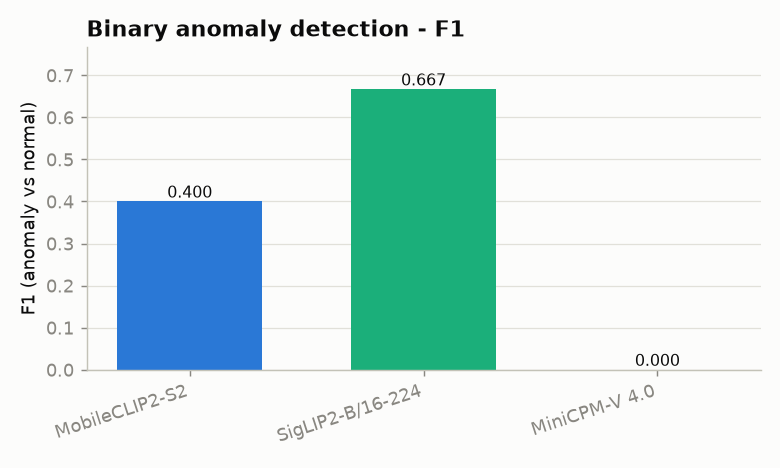

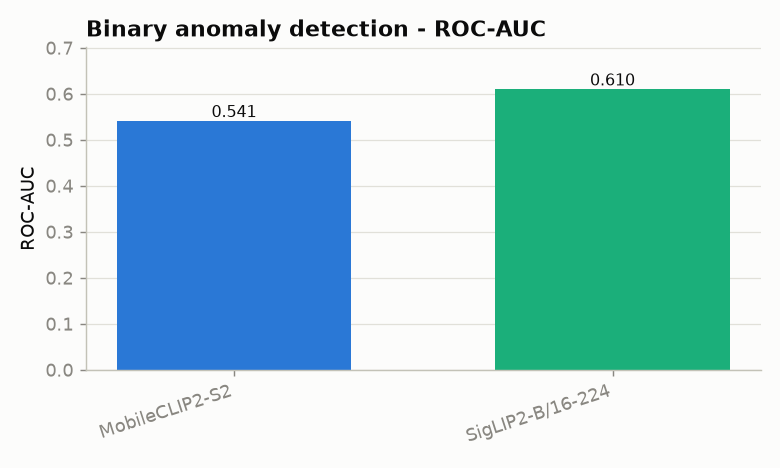

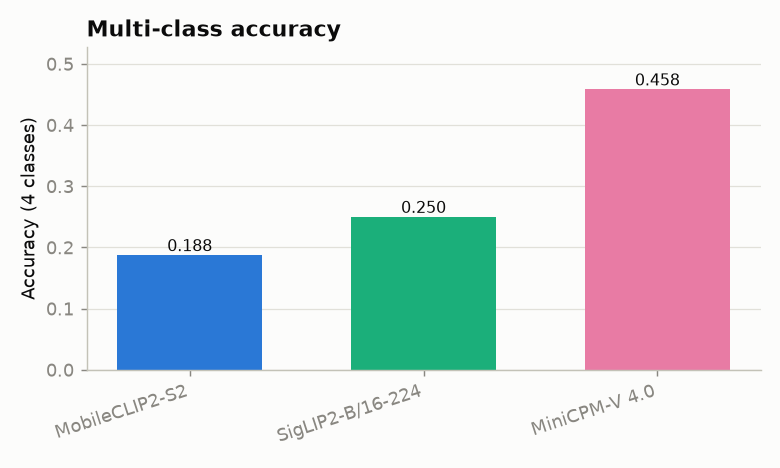

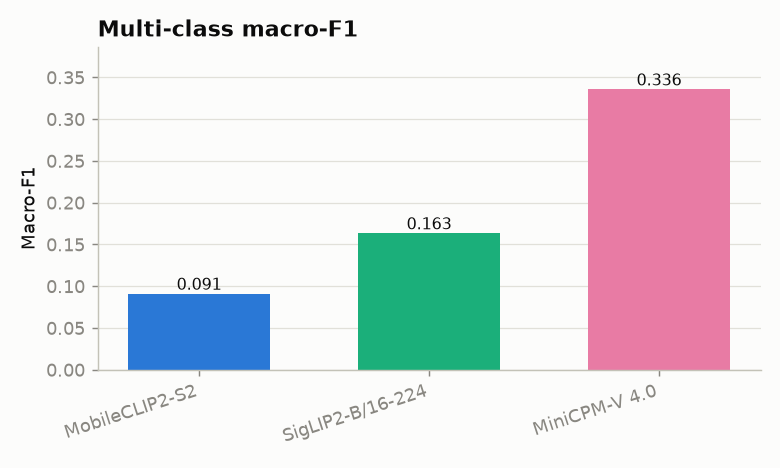

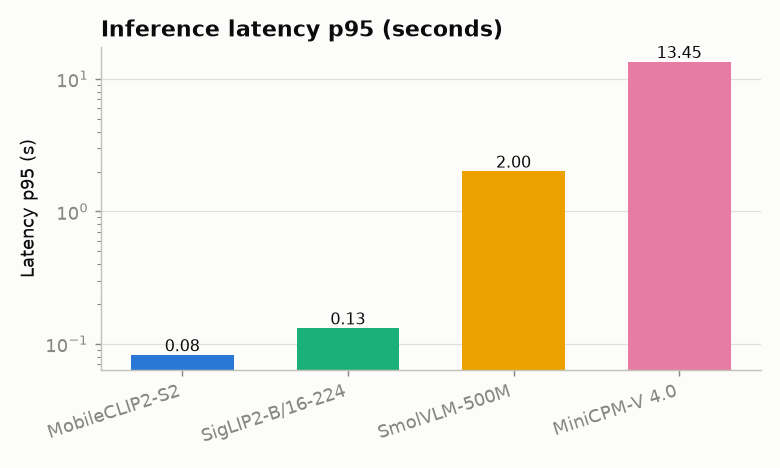

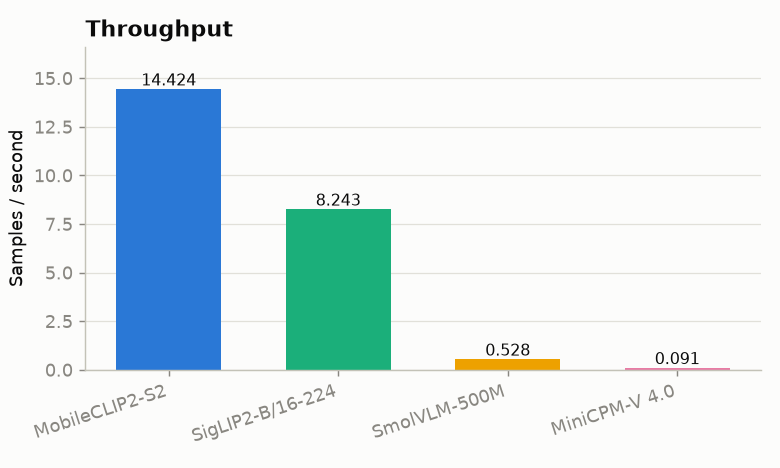

In [10]:
# ---- Show the charts --------------------------------------------------------
from IPython.display import Image, display
for name in ["binary_anomaly_detection_-_f1.png", "binary_anomaly_detection_-_roc-auc.png",
             "multi-class_accuracy.png", "multi-class_macro-f1.png",
             "inference_latency_p95_(seconds).png", "throughput.png"]:
    p = FIGDIR / name
    if p.is_file(): display(Image(filename=str(p)))

## Usability

| Model | Params (approx.) | Needs reference images? | Output type | CPU memory (fp32) | Integration effort | License |
|---|---|---|---|---|---|---|
| MobileCLIP2-S2 | ~50 M | No | softmax scores over classes (relative, not calibrated) | low (~hundreds of MiB) | low — OpenCLIP + torch | Apple weights via timm |
| SigLIP2-B/16-224 | ~380 M | No | independent sigmoid per-class scores (do **not** sum to 1) | moderate | low — transformers | Apache-2.0 (Google) |
| SmolVLM-500M | ~500 M | No | generated JSON label; **no numeric score** (no AUC) | moderate–high | medium — generative, prompt-sensitive | Apache-2.0 (HF) |
| MiniCPM-V 4.0 | ~4.1 B | No | generated JSON label; no numeric score | very high (~16 GB fp32 + buffers) | high — `trust_remote_code`, slow on CPU | Apache-2.0 (openbmb) |
| VadCLIP | varies | n/a (video) | per-frame / video anomaly score | GPU strongly preferred | **high** — separate repo, weights, temporal pipeline | see upstream |

**Reading the numbers.** CLIP-style models give fast, calibrated-ish scores and are trivial to
deploy on CPU; they are the natural first line for a real-time camera feed. VLMs (SmolVLM,
MiniCPM-V) can reason about *what* is happening but are far slower, produce no numeric score
(no ROC-AUC), and abstain more often — MiniCPM-V in particular needs ~16 GB of RAM and tens of
seconds per frame on CPU. VadCLIP targets the temporal anomalies (loitering, unattended items)
that a single still cannot establish, but it is a separate video pipeline with its own weights.

## Findings & recommendation

*(Populated after the runs above — see the tables and charts for the measured values.)*

- **Best frame-level detector on CPU:** whichever CLIP model shows the higher binary F1/AUC at
  far lower latency is the recommended default for a real-time feed; it needs no reference images
  and returns a usable score per class.
- **VLMs** are best treated as a slower, higher-recall second pass or an offline reviewer rather
  than the primary detector, given their CPU cost and lack of calibrated scores.
- **Temporal anomalies** (loitering, unattended items) need VadCLIP-style video scoring; they are
  out of scope for the single-frame comparison by design.